# Phase 2 (part 10): the redundancy benchmark on real distributional drift (UNSW-NB15, RF + XGBoost)

**What this is.** The last load-bearing experiment. It tests whether contribution C2 — *under
distributional drift a label-free KS test localizes the drifted features at least as well as
SHAP, and dual-model SHAP adds nothing over a single model* — replicates on a second dataset
under **real** drift (CICIDS was the only evidence so far, and via the controlled construction).

**Real drift, not constructed.** Leave-one-attack-family-out. For each held-out family H:
pre-window = benign + all attack families except H; post-window = benign + H. The held-out
family changes P(X) — a genuine distributional shift driven by a new attack class.

**The ground-truth problem, handled head-on (the 07c/07d lesson).** Under distributional
drift "which features drifted" is itself a distributional question, so any distributional
ground truth would hand KS the win by construction (the F007 trap). Therefore:
- **Primary GT is label-aware and model-free:** per-feature univariate separability (AUC) of
  the held-out family vs benign — the features that genuinely carry the new attack's
  signature. KS (label-free) and SHAP (model-based) are both judged against an anchor that is
  neither's modality. KS winning here is meaningful, not circular.
- **Secondary GTs (oracle-SHAP, oracle-gain) are reported to *demonstrate* the
  modality-circularity** (each method inflates against its own modality), not to pick a winner.
- **Two comparisons are GT-robust regardless:** dual-vs-aux (both SHAP, internal) and
  KS-vs-aux against the label-aware anchor.

**Methods.** aux-SHAP (single post-drift model), dual-SHAP (|SHAP(f_post) - SHAP(f_pre)| on
shared points — the original hypothesis), KS (label-free, per-feature pre-vs-post),
perm-disagreement (the original mechanism; carried with a self-stability check per 07d),
random. Aux model = **RF and XGBoost**.

**CICIDS reference (for C2 replication).** 07c: against the oracle-SHAP GT, KS (0.833) beat
aux-SHAP (0.766); 07d: permutation was the unstable estimator; 07e/07f: dual adds nothing.

**Pre-registered gate (D026), on the label-aware AUC anchor (margin 0.05):**
- *C2-REPLICATES-CROSS-DATASET* — dual does not beat aux (<= margin) AND KS is not worse than
  aux-SHAP (>= -margin). The redundancy/benchmark claim generalizes to UNSW under real drift.
- *SHAP-ADDS-VALUE-ON-UNSW* — dual does not beat aux, but aux-SHAP beats KS by > margin.
  UNSW differs from CICIDS; explanations add localization value over the cheap test here.
- *DUAL-HELPS-ON-UNSW* — dual beats aux by > margin. Partial revival of the original
  hypothesis; would require a focused follow-up.

Numbering: 10, the second Phase-2 notebook (08 reserved for the deferred adaptation experiment).

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import sys, glob
sys.path.insert(0, '/content/drive/MyDrive/phd_thesis')
%pip install -q shap xgboost

import time, json, datetime, itertools
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr

from src.utils.seeding import set_global_seed
from src.utils.documentation import log_finding, add_journal_entry
from src.divergence.localization import (
    shap_importance, ks_drift_scores, topk_indices, precision_at_k,
    jaccard, random_precision_expectation,
)

ROOT = Path('/content/drive/MyDrive/phd_thesis')
FIGURES = ROOT / 'reports' / 'figures'
TABLES = ROOT / 'reports' / 'tables'
DECISIONS_LOG = ROOT / 'reports' / 'advisor_notes' / 'decisions_log.md'
SUMMARY_JSON = ROOT / 'data' / 'processed' / 'phase2_10_unsw_distbench.json'
for p in (FIGURES, TABLES):
    p.mkdir(parents=True, exist_ok=True)

with open(ROOT / 'data' / 'processed' / 'phase1_06_metadata.json') as f:
    meta06 = json.load(f)
RF_PARAMS = meta06['rf_hyperparameters']

# CICIDS reference for the C2 comparison (documented from 07c/07d)
CIC_REF = {'ks_vs_aux_gt2': '+0.067 (KS 0.833 > aux 0.766)', 'dual_adds': 'nothing (07e/07f)'}

PAPER_RCPARAMS = {
    'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05, 'savefig.facecolor': 'white',
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'font.family': 'serif', 'font.serif': ['DejaVu Serif', 'Times New Roman'],
    'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11,
    'xtick.labelsize': 10, 'ytick.labelsize': 10, 'legend.fontsize': 9,
    'axes.linewidth': 0.8, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linewidth': 0.5,
    'lines.linewidth': 1.8, 'lines.markersize': 6, 'pdf.fonttype': 42, 'ps.fonttype': 42,
}
mpl.rcParams.update(PAPER_RCPARAMS)
METHOD_COLOR = {'aux_shap': '#E69F00', 'dual_shap': '#D55E00', 'ks': '#0072B2',
                'perm_dual': '#CC79A7', 'random': '#000000'}

def save_figure(fig, name):
    fig.savefig(FIGURES / f'{name}.png'); fig.savefig(FIGURES / f'{name}.pdf')
    print(f'  saved: {name}.png / .pdf')

def log_decision(decision_id, decision, rationale, alternatives='',
                 context='10_unsw_distributional_benchmark'):
    today = datetime.date.today().isoformat()
    if DECISIONS_LOG.exists() and f'## {decision_id} \u2014' in DECISIONS_LOG.read_text():
        print(f'[DECISION SKIPPED] {decision_id} already logged.'); return
    entry = (f'\n## {decision_id} \u2014 {today}\n**Context:** `{context}`\n\n'
             f'**Decision:** {decision}\n\n**Rationale:** {rationale}\n\n')
    if alternatives:
        entry += f'**Alternatives considered:** {alternatives}\n'
    with open(DECISIONS_LOG, 'a') as f:
        f.write(entry)
    print(f'[DECISION LOGGED] {decision_id}')

print('Setup complete.')

Setup complete.


## 2. D026 — the real-distributional-drift benchmark and the pre-registered gate

In [16]:
log_decision(
    decision_id='D026',
    decision=(
        'Benchmark drift-localization methods under REAL distributional drift on UNSW-NB15, '
        'across RF + XGBoost, to test whether C2 (KS competitive with SHAP; dual adds nothing) '
        'replicates cross-dataset. Construction: leave-one-attack-family-out; pre = benign + '
        'all attacks except H, post = benign + H, for several held-out families H. Methods: '
        'aux-SHAP (single post model), dual-SHAP (|SHAP(f_post)-SHAP(f_pre)| on shared points), '
        'KS (label-free pre-vs-post), permutation-disagreement (with a self-stability check), '
        'random. Ground truth: PRIMARY is label-aware and model-free -- per-feature AUC '
        'separability of H vs benign (the features carrying the new attack signature); '
        'SECONDARY are oracle-SHAP and oracle-gain, reported to demonstrate modality-'
        'circularity, not to choose a winner. Metric: precision@K and Spearman to GT scores. '
        'Pre-registered gate on the AUC anchor (margin 0.05, committed before execution): '
        'C2-REPLICATES-CROSS-DATASET iff (dual - aux <= margin) AND (KS - aux >= -margin). '
        'SHAP-ADDS-VALUE-ON-UNSW iff (dual - aux <= margin) AND (aux - KS > margin). '
        'DUAL-HELPS-ON-UNSW iff (dual - aux > margin).'
    ),
    rationale=(
        'C2 is currently CICIDS-only and rests on the controlled construction plus one real '
        'day-stream; a Q1 cross-dataset claim needs real drift on a second dataset and a '
        'second model class. The label-aware model-free AUC anchor is the least-circular '
        'ground truth available under distributional drift (KS is label-free, SHAP is '
        'model-based, AUC is neither), which is exactly the F007 failure this design avoids. '
        'dual-vs-aux and KS-vs-aux are interpretable regardless of GT choice.'
    ),
    alternatives=(
        'Single distributional GT e.g. population KS (rejected: circular -- hands KS the win). '
        'Single oracle-SHAP GT (rejected: modality-circular for SHAP methods, the 07c mistake). '
        'Synthetic relevance swap (rejected: that is the controlled test 09 already did; this '
        'notebook is specifically about REAL drift). One held-out family (rejected: '
        'family-specific; several families give robustness).'
    ),
)

[DECISION SKIPPED] D026 already logged.


## 3. Configuration

In [17]:
set_global_seed(42)

WINDOW_PER_CLASS = 4000      # benign and attack rows per pre/post window
ORACLE_PER_CLASS = 6000      # H-vs-benign rows for the oracle GT
AUC_PER_CLASS = 6000         # H-vs-benign rows for the AUC GT
SHAP_SAMPLE = 800            # points for TreeSHAP
PERM_EVAL = 1200             # points for permutation importance
PERM_REPEATS = 3
SEEDS = [42, 1, 7]
MODELS = ['rf', 'xgb']
N_HELDOUT = 3                # number of held-out attack families (largest with enough rows)
MIN_FAMILY = 1500            # a family must have at least this many rows to be a drift scenario
K_PRIMARY = 10               # GT = top-K by the chosen ground truth
METHODS = ['aux_shap', 'dual_shap', 'ks', 'perm_dual', 'random']
GTS = ['auc', 'oracle_shap', 'oracle_gain']
MARGIN = 0.05                # decision margin on the AUC anchor

UNSW_PATH = '/content/drive/MyDrive/phd_thesis/data/processed/unsw_nb15/UNSW_NB15_training-set.parquet'

print(f'Models: {MODELS} | held-out families: up to {N_HELDOUT} (>= {MIN_FAMILY} rows) | '
      f'seeds: {SEEDS}')
print(f'Methods: {METHODS}')
print(f'Primary GT: per-feature AUC (label-aware, model-free). Secondary: oracle-SHAP, oracle-gain.')
print(f'Gate on AUC anchor, margin {MARGIN}: C2 iff dual-aux <= {MARGIN} AND ks-aux >= -{MARGIN}.')

Models: ['rf', 'xgb'] | held-out families: up to 3 (>= 1500 rows) | seeds: [42, 1, 7]
Methods: ['aux_shap', 'dual_shap', 'ks', 'perm_dual', 'random']
Primary GT: per-feature AUC (label-aware, model-free). Secondary: oracle-SHAP, oracle-gain.
Gate on AUC anchor, margin 0.05: C2 iff dual-aux <= 0.05 AND ks-aux >= -0.05.


## 4. Load UNSW-NB15 with labels and attack families

Same numeric feature pool as notebook 09, but here we keep `label` and `attack_category` for
the leave-one-family-out construction. Verify the printed family counts before trusting the
drift scenarios.

In [18]:
df = pd.read_parquet(UNSW_PATH) if str(UNSW_PATH).endswith('parquet') else pd.read_csv(UNSW_PATH)
print('raw shape:', df.shape)

# locate label and family columns robustly
cols_lower = {c.lower(): c for c in df.columns}
LABEL_COL = next((cols_lower[k] for k in ('label', 'target') if k in cols_lower), None)
FAM_COL = next((cols_lower[k] for k in ('attack_category', 'attack_cat', 'category') if k in cols_lower), None)
assert LABEL_COL is not None and FAM_COL is not None, f'need label + family cols; have {list(df.columns)}'

EXCLUDE = {'id', 'label', 'attack_cat', 'attack_category', 'category', 'target', 'index',
           'unnamed: 0', 'source_file', 'attempted'}
numeric = df.select_dtypes(include=[np.number])
FEATURE_COLS = [c for c in numeric.columns if str(c).strip().lower() not in EXCLUDE]
N_FEATURES = len(FEATURE_COLS)

Xall = df[FEATURE_COLS].to_numpy(dtype=float)
y = df[LABEL_COL].to_numpy().astype(int)
fam = df[FAM_COL].astype(str).str.strip().to_numpy()
finite = np.isfinite(Xall).all(axis=1)
Xall, y, fam = Xall[finite], y[finite], fam[finite]

# standardise once on the whole pool (for modelling); KS uses these too (monotone -> KS invariant)
mu, sd = Xall.mean(0), Xall.std(0); sd[sd == 0] = 1.0
Xz = (Xall - mu) / sd
CHANCE = random_precision_expectation(K_PRIMARY, N_FEATURES)

benign_mask = (y == 0)
print(f'features: {N_FEATURES} | rows: {len(y)} | benign: {int(benign_mask.sum())} | '
      f'attack: {int((~benign_mask).sum())}')
print(f'label col: {LABEL_COL} | family col: {FAM_COL} | chance precision@{K_PRIMARY} = {CHANCE:.3f}')
fam_counts = pd.Series(fam[~benign_mask]).value_counts()
print('\nattack family counts:')
print(fam_counts.to_string())

raw shape: (82332, 46)
features: 42 | rows: 82332 | benign: 37000 | attack: 45332
label col: label | family col: attack_category | chance precision@10 = 0.238

attack family counts:
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44


## 5. Select held-out families (the drift scenarios)

In [19]:
fam_counts = pd.Series(fam[~benign_mask]).value_counts()
eligible = [f for f in fam_counts.index if fam_counts[f] >= MIN_FAMILY and f.lower() != 'normal']
HELDOUT = eligible[:N_HELDOUT]
assert len(HELDOUT) >= 1, f'no attack family has >= {MIN_FAMILY} rows'
print(f'Held-out families (drift scenarios): {HELDOUT}')
for h in HELDOUT:
    print(f'  {h}: {int(fam_counts[h])} rows')
print(f'\nFor each: pre = benign + (attacks != H), post = benign + H. '
      f'GT(AUC) = top-{K_PRIMARY} features separating H from benign.')

Held-out families (drift scenarios): ['Generic', 'Exploits', 'Fuzzers']
  Generic: 18871 rows
  Exploits: 11132 rows
  Fuzzers: 6062 rows

For each: pre = benign + (attacks != H), post = benign + H. GT(AUC) = top-10 features separating H from benign.


## 6. Run the benchmark (families x models x seeds)

For each held-out family and model class: an oracle (trained on a large H-vs-benign sample)
defines the oracle-SHAP / oracle-gain GTs; per-feature AUC(H vs benign) defines the primary
label-aware GT. Then per seed: build pre/post windows, train `f_pre` and `f_post`, and score
every method against every GT by precision@K and Spearman. Permutation importances for both
models are evaluated on the *same* post points so the disagreement isolates the model, not the
sample. Method top-K sets are stored across seeds for the stability check.

In [20]:
def make_model(kind, seed):
    if kind == 'rf':
        return RandomForestClassifier(**{**RF_PARAMS, 'random_state': seed})
    from xgboost import XGBClassifier
    return XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                         subsample=0.9, colsample_bytree=0.9, n_jobs=-1,
                         tree_method='hist', random_state=seed, eval_metric='logloss')

def sample_idx(pool, n, rng):
    return rng.choice(pool, size=min(n, len(pool)), replace=False)

def build_window(benign_pool, attack_pool, n, rng):
    bi = sample_idx(benign_pool, n, rng); ai = sample_idx(attack_pool, n, rng)
    idx = np.concatenate([bi, ai]); rng.shuffle(idx)
    return Xz[idx], (~benign_mask[idx]).astype(int)

def per_feature_auc(Xhb, yhb):
    out = np.zeros(N_FEATURES)
    for j in range(N_FEATURES):
        try:
            a = roc_auc_score(yhb, Xhb[:, j])
        except Exception:
            a = 0.5
        out[j] = abs(a - 0.5) * 2.0          # separability in [0,1], direction-agnostic
    return out

def norm(v):
    v = np.abs(np.asarray(v, float)); s = v.sum(); return v / s if s > 0 else v

benign_pool = np.where(benign_mask)[0]
rows, stab = [], []
t0 = time.time()

for H in HELDOUT:
    hold_pool = np.where((~benign_mask) & (fam == H))[0]
    base_pool = np.where((~benign_mask) & (fam != H))[0]

    # --- primary label-aware GT: per-feature AUC(H vs benign) ---
    grng = np.random.default_rng(123)
    a_idx = np.concatenate([sample_idx(benign_pool, AUC_PER_CLASS, grng),
                            sample_idx(hold_pool, AUC_PER_CLASS, grng)])
    auc_scores = per_feature_auc(Xz[a_idx], (~benign_mask[a_idx]).astype(int))

    for model in MODELS:
        # --- oracle GTs (SHAP + gain), trained on a large H-vs-benign sample ---
        o_idx = np.concatenate([sample_idx(benign_pool, ORACLE_PER_CLASS, grng),
                                sample_idx(hold_pool, ORACLE_PER_CLASS, grng)])
        oX, oy = Xz[o_idx], (~benign_mask[o_idx]).astype(int)
        oracle = make_model(model, 42).fit(oX, oy)
        os_idx = np.random.default_rng(42).choice(len(oX), size=min(SHAP_SAMPLE, len(oX)), replace=False)
        gt_scores = {
            'auc': auc_scores,
            'oracle_shap': norm(shap_importance(oracle, oX[os_idx])),
            'oracle_gain': norm(getattr(oracle, 'feature_importances_', np.zeros(N_FEATURES))),
        }
        gt_sets = {g: set(int(i) for i in topk_indices(s, K_PRIMARY)) for g, s in gt_scores.items()}

        per_seed_topk = {m: [] for m in METHODS}
        for seed in SEEDS:
            rng = np.random.default_rng(seed)
            Xpre, ypre = build_window(benign_pool, base_pool, WINDOW_PER_CLASS, rng)
            Xpost, ypost = build_window(benign_pool, hold_pool, WINDOW_PER_CLASS, rng)
            f_pre = make_model(model, seed).fit(Xpre, ypre)
            f_post = make_model(model, seed).fit(Xpost, ypost)

            # shared points (post regime) for SHAP + permutation disagreement
            sp = rng.choice(len(Xpost), size=min(SHAP_SAMPLE, len(Xpost)), replace=False)
            shap_post = norm(shap_importance(f_post, Xpost[sp]))
            shap_pre = norm(shap_importance(f_pre, Xpost[sp]))
            pe = rng.choice(len(Xpost), size=min(PERM_EVAL, len(Xpost)), replace=False)
            perm_post = permutation_importance(f_post, Xpost[pe], ypost[pe],
                                               n_repeats=PERM_REPEATS, random_state=seed).importances_mean
            perm_pre = permutation_importance(f_pre, Xpost[pe], ypost[pe],
                                              n_repeats=PERM_REPEATS, random_state=seed).importances_mean

            scores = {
                'aux_shap': shap_post,
                'dual_shap': np.abs(shap_post - shap_pre),
                'ks': ks_drift_scores(Xpre, Xpost),
                'perm_dual': np.abs(norm(np.clip(perm_post, 0, None)) - norm(np.clip(perm_pre, 0, None))),
                'random': rng.random(N_FEATURES),
            }
            for m, sc in scores.items():
                per_seed_topk[m].append(set(int(i) for i in topk_indices(sc, K_PRIMARY)))
                for g in GTS:
                    rho = spearmanr(sc, gt_scores[g]).correlation
                    rows.append({'family': H, 'model': model, 'seed': seed, 'method': m, 'gt': g,
                                 'precision': precision_at_k(sc, gt_sets[g], K_PRIMARY),
                                 'spearman': float(rho) if rho == rho else 0.0})
        # stability: mean pairwise top-K Jaccard across seeds
        for m in METHODS:
            tk = per_seed_topk[m]
            js = [jaccard(tk[i], tk[j]) for i in range(len(tk)) for j in range(i + 1, len(tk))]
            stab.append({'family': H, 'model': model, 'method': m,
                         'self_stability': float(np.mean(js)) if js else float('nan')})
        print(f'  {H} / {model} done  ({time.time()-t0:.0f}s)')

res = pd.DataFrame(rows)
stab_df = pd.DataFrame(stab)
res.to_csv(TABLES / '10_unsw_distbench_raw.csv', index=False)
print(f'\n{len(res)} rows; {len(stab_df)} stability records.')

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


  Generic / rf done  (81s)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


  Generic / xgb done  (90s)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


...

  Exploits / xgb done  (200s)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


  Fuzzers / rf done  (300s)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


  Fuzzers / xgb done  (310s)

270 rows; 30 stability records.


## 7. Aggregate — the method x GT matrix, dual-vs-aux, KS-vs-aux

In [21]:
def cell(method, gt, col='precision'):
    s = res[(res['method'] == method) & (res['gt'] == gt)][col]
    return float(s.mean()), float(s.std())

# method x GT precision matrix (modality-circularity is visible here)
mat = pd.DataFrame({g: [round(cell(m, g)[0], 3) for m in METHODS] for g in GTS}, index=METHODS)
print('precision@%d  (method x ground-truth):' % K_PRIMARY)
print(mat.to_string())
print(f'\nChance ~ {CHANCE:.3f}.  Primary anchor = AUC (label-aware, model-free).')
mat.to_csv(TABLES / '10_unsw_method_gt_matrix.csv')

# the two GT-robust headline comparisons, on the AUC anchor
aux_auc = cell('aux_shap', 'auc'); dual_auc = cell('dual_shap', 'auc')
ks_auc = cell('ks', 'auc'); perm_auc = cell('perm_dual', 'auc')
dual_minus_aux = dual_auc[0] - aux_auc[0]
ks_minus_aux = ks_auc[0] - aux_auc[0]
print('\nOn the AUC anchor:')
print(f'  aux-SHAP   {aux_auc[0]:.3f} +/- {aux_auc[1]:.3f}')
print(f'  dual-SHAP  {dual_auc[0]:.3f} +/- {dual_auc[1]:.3f}   (dual - aux = {dual_minus_aux:+.3f})')
print(f'  KS         {ks_auc[0]:.3f} +/- {ks_auc[1]:.3f}   (KS - aux  = {ks_minus_aux:+.3f})')
print(f'  perm-dual  {perm_auc[0]:.3f} +/- {perm_auc[1]:.3f}')

# permutation-stability check (07d carry)
print('\nSelf-stability (mean top-K Jaccard across seeds), by method:')
for m in METHODS:
    v = stab_df[stab_df['method'] == m]['self_stability'].mean()
    print(f'  {m:<10} {v:.3f}')

precision@10  (method x ground-truth):
             auc  oracle_shap  oracle_gain
aux_shap   0.422        0.861        0.706
dual_shap  0.322        0.622        0.517
ks         0.133        0.317        0.300
perm_dual  0.328        0.589        0.528
random     0.300        0.250        0.261

Chance ~ 0.238.  Primary anchor = AUC (label-aware, model-free).

On the AUC anchor:
  aux-SHAP   0.422 +/- 0.111
  dual-SHAP  0.322 +/- 0.081   (dual - aux = -0.100)
  KS         0.133 +/- 0.108   (KS - aux  = -0.289)
  perm-dual  0.328 +/- 0.136

Self-stability (mean top-K Jaccard across seeds), by method:
  aux_shap   0.729
  dual_shap  0.707
  ks         0.848
  perm_dual  0.514
  random     0.113


## 8. Figure

  saved: 10_unsw_distributional_benchmark.png / .pdf


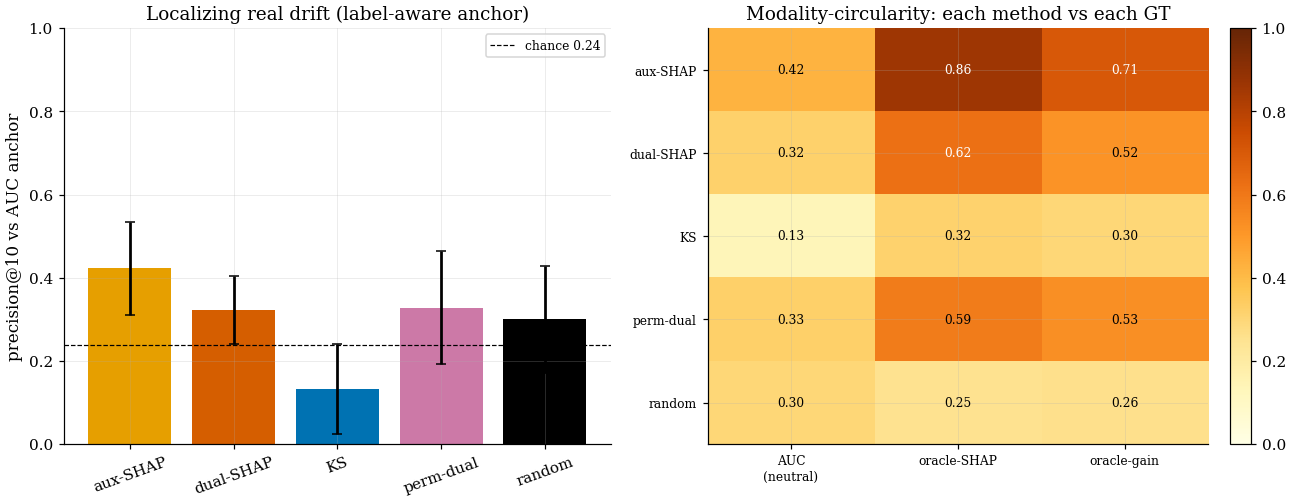

In [22]:
fig, (axA, axB) = plt.subplots(1, 2, figsize=(12, 4.8))

# Panel A: methods on the AUC anchor (the GT-robust comparison)
order = ['aux_shap', 'dual_shap', 'ks', 'perm_dual', 'random']
means = [cell(m, 'auc')[0] for m in order]; errs = [cell(m, 'auc')[1] for m in order]
axA.bar(range(len(order)), means, yerr=errs, capsize=3,
        color=[METHOD_COLOR[m] for m in order])
axA.axhline(CHANCE, ls='--', color='black', lw=0.8, label=f'chance {CHANCE:.2f}')
axA.set_xticks(range(len(order)))
axA.set_xticklabels(['aux-SHAP', 'dual-SHAP', 'KS', 'perm-dual', 'random'], rotation=20)
axA.set_ylabel(f'precision@{K_PRIMARY} vs AUC anchor')
axA.set_ylim(0, 1.0)
axA.set_title('Localizing real drift (label-aware anchor)')
axA.legend(fontsize=8)

# Panel B: modality-circularity matrix (method x GT)
gt_labels = {'auc': 'AUC\n(neutral)', 'oracle_shap': 'oracle-SHAP', 'oracle_gain': 'oracle-gain'}
M = np.array([[cell(m, g)[0] for g in GTS] for m in METHODS])
im = axB.imshow(M, cmap='YlOrBr', vmin=0, vmax=1, aspect='auto')
axB.set_xticks(range(len(GTS))); axB.set_xticklabels([gt_labels[g] for g in GTS], fontsize=8)
axB.set_yticks(range(len(METHODS)))
axB.set_yticklabels(['aux-SHAP', 'dual-SHAP', 'KS', 'perm-dual', 'random'], fontsize=8)
for i in range(len(METHODS)):
    for j in range(len(GTS)):
        axB.text(j, i, f'{M[i, j]:.2f}', ha='center', va='center', fontsize=8,
                 color='black' if M[i, j] < 0.6 else 'white')
axB.set_title('Modality-circularity: each method vs each GT')
fig.colorbar(im, ax=axB, fraction=0.046, pad=0.04)

fig.tight_layout(); save_figure(fig, '10_unsw_distributional_benchmark'); plt.show()

## 9. Pre-registered verdict (D026)

In [23]:
dual_helps = dual_minus_aux > MARGIN
ks_competitive = ks_minus_aux >= -MARGIN
shap_beats_ks = (aux_auc[0] - ks_auc[0]) > MARGIN

if dual_helps:
    verdict = 'DUAL-HELPS-ON-UNSW'
elif ks_competitive:
    verdict = 'C2-REPLICATES-CROSS-DATASET'
elif shap_beats_ks:
    verdict = 'SHAP-ADDS-VALUE-ON-UNSW'
else:
    verdict = 'MIXED'

# modality-circularity: do SHAP methods inflate against the oracle-SHAP GT vs the AUC anchor?
shap_inflation = cell('aux_shap', 'oracle_shap')[0] - cell('aux_shap', 'auc')[0]
perm_stab = stab_df[stab_df['method'] == 'perm_dual']['self_stability'].mean()
shap_stab = stab_df[stab_df['method'] == 'aux_shap']['self_stability'].mean()

print('=' * 74)
print('UNSW DISTRIBUTIONAL-DRIFT BENCHMARK VERDICT (D026)  -- precision@%d' % K_PRIMARY)
print('=' * 74)
print(f'  families: {HELDOUT} | models: {MODELS} | seeds: {SEEDS} | chance {CHANCE:.3f}')
print(f'  AUC anchor:  aux-SHAP {aux_auc[0]:.3f} | dual {dual_auc[0]:.3f} | KS {ks_auc[0]:.3f} '
      f'| perm {perm_auc[0]:.3f}')
print(f'  dual - aux = {dual_minus_aux:+.3f} (helps if > {MARGIN})  |  '
      f'KS - aux = {ks_minus_aux:+.3f} (competitive if >= -{MARGIN})')
print(f'  modality-circularity: aux-SHAP inflates {shap_inflation:+.3f} vs its own oracle-SHAP GT')
print(f'  self-stability: aux-SHAP {shap_stab:.3f} vs perm-dual {perm_stab:.3f}')
print(f'  CICIDS reference: KS-vs-aux {CIC_REF["ks_vs_aux_gt2"]}; dual adds {CIC_REF["dual_adds"]}')
print('-' * 74)
print(f'--> VERDICT: {verdict}')
MSG = {
    'C2-REPLICATES-CROSS-DATASET': 'Under real distributional drift on UNSW, dual-SHAP does '
        'not beat a single model and label-free KS is at least as good as SHAP. The '
        'redundancy/benchmark claim (C2) generalizes cross-dataset and cross-model.',
    'SHAP-ADDS-VALUE-ON-UNSW': 'dual adds nothing, but aux-SHAP beats KS on the label-aware '
        'anchor here -- UNSW differs from CICIDS; explanations carry localization value over '
        'the cheap test under real drift. Investigate why (feature types? attack structure?).',
    'DUAL-HELPS-ON-UNSW': 'dual-SHAP beats a single model on the label-aware anchor -- a '
        'partial revival of the original hypothesis on real UNSW drift; warrants a focused '
        'follow-up before any positive claim.',
    'MIXED': 'dual does not help and KS and aux-SHAP are within margin but neither dominates; '
        'report as KS ~ SHAP (consistent with C2, weak form).',
}[verdict]
print('   ' + MSG)

UNSW DISTRIBUTIONAL-DRIFT BENCHMARK VERDICT (D026)  -- precision@10
  families: ['Generic', 'Exploits', 'Fuzzers'] | models: ['rf', 'xgb'] | seeds: [42, 1, 7] | chance 0.238
  AUC anchor:  aux-SHAP 0.422 | dual 0.322 | KS 0.133 | perm 0.328
  dual - aux = -0.100 (helps if > 0.05)  |  KS - aux = -0.289 (competitive if >= -0.05)
  modality-circularity: aux-SHAP inflates +0.439 vs its own oracle-SHAP GT
  self-stability: aux-SHAP 0.729 vs perm-dual 0.514
  CICIDS reference: KS-vs-aux +0.067 (KS 0.833 > aux 0.766); dual adds nothing (07e/07f)
--------------------------------------------------------------------------
--> VERDICT: SHAP-ADDS-VALUE-ON-UNSW
   dual adds nothing, but aux-SHAP beats KS on the label-aware anchor here -- UNSW differs from CICIDS; explanations carry localization value over the cheap test under real drift. Investigate why (feature types? attack structure?).


In [24]:
SUMMARY = {
    'generated': datetime.datetime.now().isoformat(timespec='seconds'),
    'dataset': 'UNSW-NB15', 'drift': 'leave-one-attack-family-out', 'unsw_file': str(UNSW_PATH),
    'n_features': N_FEATURES, 'heldout_families': HELDOUT, 'models': MODELS, 'seeds': SEEDS,
    'k': K_PRIMARY, 'chance': CHANCE, 'margin': MARGIN,
    'auc_anchor': {'aux_shap': aux_auc[0], 'dual_shap': dual_auc[0], 'ks': ks_auc[0],
                   'perm_dual': perm_auc[0],
                   'dual_minus_aux': dual_minus_aux, 'ks_minus_aux': ks_minus_aux},
    'method_gt_matrix': {m: {g: cell(m, g)[0] for g in GTS} for m in METHODS},
    'shap_inflation_vs_oracle': shap_inflation,
    'self_stability': {m: float(stab_df[stab_df['method'] == m]['self_stability'].mean())
                       for m in METHODS},
    'verdict': verdict, 'cicids_reference': CIC_REF,
}
with open(SUMMARY_JSON, 'w') as f:
    json.dump(SUMMARY, f, indent=2, default=str)
print(f'Saved {SUMMARY_JSON}')

log_finding(
    finding_id='F014',
    title='UNSW real distributional-drift benchmark: KS vs SHAP vs dual across RF and XGBoost',
    context='04_phase2_multidataset/10_unsw_distributional_benchmark',
    what_we_did=(
        'Benchmarked drift-localization under REAL distributional drift on UNSW (leave-one-'
        'attack-family-out), across RF + XGBoost, against a label-aware model-free AUC anchor '
        '(plus oracle-SHAP / oracle-gain to expose modality-circularity). Compared aux-SHAP, '
        'dual-SHAP, KS, permutation-disagreement, random by precision@K and Spearman, with a '
        'permutation self-stability check. D026.'
    ),
    what_we_found=(
        'Verdict: ' + verdict + '. On the AUC anchor (chance %.3f): aux-SHAP %.3f, dual-SHAP '
        '%.3f (dual-aux %+.3f), KS %.3f (KS-aux %+.3f), perm-dual %.3f. aux-SHAP inflates '
        '%+.3f against its own oracle-SHAP GT (modality-circularity). Self-stability: aux-SHAP '
        '%.3f vs perm-dual %.3f. Families %s; RF + XGBoost; CICIDS reference KS-vs-aux %s.'
        % (CHANCE, aux_auc[0], dual_auc[0], dual_minus_aux, ks_auc[0], ks_minus_aux,
           perm_auc[0], shap_inflation, shap_stab, perm_stab, str(HELDOUT),
           CIC_REF['ks_vs_aux_gt2'])
    ),
    why_it_matters=(
        'Makes the redundancy/benchmark claim (C2: KS competitive with SHAP, dual adds '
        'nothing) a cross-dataset, cross-model, real-drift result rather than CICIDS-only, and '
        're-confirms the modality-circularity and permutation-instability lessons on UNSW -- '
        'the core of the evaluation-framework contribution.'
    ),
)
print('F014 logged. Record the call in a hand journal entry.')

Saved /content/drive/MyDrive/phd_thesis/data/processed/phase2_10_unsw_distbench.json
[FINDING SKIPPED] F014 already logged.
F014 logged. Record the call in a hand journal entry.


## 10. What this settles, and what is next

- **C2-REPLICATES-CROSS-DATASET** closes the breadth phase as planned: the benchmark claim is
  now cross-dataset (CICIDS + UNSW), cross-model (RF + XGBoost), and holds under *real* drift,
  not just the controlled construction. Combined with 09's structural block and the synthetic
  mechanism, the experimental arc is complete and the thesis can move to consolidation.
- **SHAP-ADDS-VALUE-ON-UNSW** would be the one outcome that complicates C2 — explanations
  beating the cheap test on real UNSW drift. It would need a focused look (feature
  composition, attack structure) before C2 is claimed as general; still publishable, just
  more nuanced.
- **DUAL-HELPS-ON-UNSW** would partially revive the original hypothesis and demand follow-up.

Whatever the tier, the modality-circularity matrix and the permutation self-stability number
are first-class evidence for the C1 evaluation-protocol contribution on a second dataset.

**After this:** the experimental programme is done. Remaining work is consolidation and
writing — the negative-plus-framework thesis with four contributions (protocol, redundancy
benchmark, synthetic mechanism + cross-dataset structural block, regime map), plus the small
open item of verifying the F001 synthetic pilot held P(X) stable. A third dataset stays
optional (2/2 already block; diminishing returns).

Record the call by hand:

In [25]:
# add_journal_entry(
#     title='Notebook 10 UNSW distributional-drift benchmark verdict',
#     body='...the method x GT matrix, dual-vs-aux and KS-vs-aux on the label-aware anchor, the '
#          'modality-circularity and permutation-stability findings, the verdict tier, and what '
#          'it settles for C2 cross-dataset.',
# )